# Lecture 7 — Convolutional and Residual Networks
## Lab Notebook · Deep Learning · UCU

In Notebook 5, we trained a deep MLP on tabular data (UCI Covertype) and learned how to *measure* whether it generalizes — train/val/test discipline, regularization, hyperparameter search. In this notebook, we move to **images**, where MLPs hit a hard ceiling and convolutional layers replace the dense weight matrix with a small **shared kernel**.

We will work with the **Oxford-IIIT Pet** dataset and use it three different ways:

1. **Part 1** — Build a small CNN *from scratch* for binary cat-vs-dog classification.
2. **Part 2** — Fine-tune a *pretrained* ResNet18 for 37-breed classification.
3. **Part 3** — Build and train a small *U-Net* for foreground/background segmentation.

The same pixels feed three networks with three different targets. By the end you will have an end-to-end mental model for the three computer-vision workflows that dominate industry.

### By the end of this notebook, you will:

1. Build a small CNN from scratch with `nn.Conv2d`, `nn.BatchNorm2d`, `nn.MaxPool2d`, and an `nn.AdaptiveAvgPool2d` head, and reason about its receptive field and parameter count.
2. Fine-tune a pretrained `resnet18` from `torchvision.models` on a new classification task by freezing the backbone and replacing the final layer.
3. Build a small **U-Net** for foreground/background segmentation, including encoder/decoder blocks and **skip connections**, and train it with `CrossEntropyLoss` on a per-pixel target.
4. Visualize segmentation predictions and qualitatively probe the model's generalization on an out-of-distribution image.

### Useful references

| Topic | Link |
|---|---|
| `nn.Conv2d`, `nn.BatchNorm2d`, `nn.MaxPool2d`, `nn.AdaptiveAvgPool2d`, `nn.ConvTranspose2d` | https://pytorch.org/docs/stable/nn.html |
| Pretrained models | https://pytorch.org/vision/stable/models.html |
| `OxfordIIITPet` dataset | https://pytorch.org/vision/stable/generated/torchvision.datasets.OxfordIIITPet.html |
| U-Net (Ronneberger et al., 2015) | https://arxiv.org/abs/1505.04597 |
| Lecture 7 notes | `../../lectures/lecture 7/notes.md` |
| Prince — *Understanding Deep Learning* | Ch. 10–11 |


---
## Setup

In [2]:
# Colab setup (no-op locally)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q torch torchvision torchinfo


In [3]:
import os, time, warnings
warnings.filterwarnings('ignore')
from io import BytesIO
import urllib.request

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt

torch.manual_seed(42); np.random.seed(42)

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else ('mps' if torch.backends.mps.is_available() else 'cpu')
)
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

# UCU color palette
C1, C2, C3 = '#19326E', '#50ACB0', '#CD742A'
C4, C5, C6, C7 = '#A3477F', '#907FAB', '#4294CC', '#89A943'

if device.type == 'cpu':
    print('\n[!] No GPU detected. Part 2 (ResNet at 224x224) and Part 3 (U-Net) will be slow on CPU.')


Device: cuda
PyTorch: 2.10.0+cu128


### Download the dataset (~800 MB, run once)

We use **Oxford-IIIT Pet**: 7,349 photos of 37 breeds (cats and dogs), each annotated with the breed *and* a per-pixel **trimap** (foreground / background / boundary). We will load it three different ways via `target_types`:

- `'binary-category'` → `0` = cat, `1` = dog (Part 1)
- `'category'` → `0`…`36`, one per breed (Part 2)
- `'segmentation'` → trimap PIL image (Part 3)


In [4]:
DATA_ROOT = './data'
os.makedirs(DATA_ROOT, exist_ok=True)

# Trigger download once with download=True
_ = OxfordIIITPet(root=DATA_ROOT, split='trainval', target_types='category', download=True)
_ = OxfordIIITPet(root=DATA_ROOT, split='test',     target_types='category', download=True)
print('Dataset downloaded.')


100%|██████████| 792M/792M [00:35<00:00, 22.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.7MB/s]


Dataset downloaded.


In [5]:
# ImageNet normalization stats (used by all three parts)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


> **Practical callout — ImageNet normalization is the norm.**
> When using `torchvision` pretrained weights, always preprocess with the ImageNet mean/std the model was trained on. Even when training from scratch on natural photos, those values are sane defaults — they roughly center each channel on zero with unit variance.


---
## Part 1 — Build a CNN from scratch (~25 min)

The lecture's MNIST-1D experiment showed that a 2,050-parameter conv net beats a 150,000-parameter MLP on the same task. Convolution is best understood as a **strong inductive bias** that matches the symmetries of image data.

We will build a small VGG-style CNN — three `Conv → BN → ReLU → MaxPool` blocks plus a head — and train it to classify cats vs. dogs at 64×64.


### Exercise 1.1 — Build the data loaders

Load `OxfordIIITPet` with `target_types='binary-category'` for both splits at **64×64** with ImageNet normalization. The training transform should include a `RandomHorizontalFlip` (it is a free 2× data-augmentation since pet photos are not orientation-sensitive); the eval transform should not. Do not forget to include image normalization, using `IMAGENET_MEAN` and `IMAGENET_STD`. Use `batch_size=64` for train and 128 for test, `shuffle=True` for train only, `num_workers=2`.

In [6]:
SIZE_P1 = 64

# YOUR CODE HERE: tf_p1_train, tf_p1_eval (use IMAGENET_MEAN / IMAGENET_STD)
tf_p1_train = transforms.Compose([
    transforms.Resize((SIZE_P1, SIZE_P1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
tf_p1_eval = transforms.Compose([
    transforms.Resize((SIZE_P1, SIZE_P1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

])

train_p1 = OxfordIIITPet(DATA_ROOT, split='trainval', target_types='binary-category', transform=tf_p1_train)
test_p1  = OxfordIIITPet(DATA_ROOT, split='test',     target_types='binary-category', transform=tf_p1_eval)
print(f'Train: {len(train_p1)}   Test: {len(test_p1)}')

img, y = train_p1[0]
print(f'Image shape: {tuple(img.shape)}   Label: {y}  (0=cat, 1=dog)')

# YOUR CODE HERE: train_loader_p1, test_loader_p1
train_loader_p1 = DataLoader(
    train_p1,
    batch_size=64,
    shuffle=True,
    num_workers=2
    )
test_loader_p1  = DataLoader(
    test_p1,
    batch_size=128,
    shuffle=False,
    num_workers=2
    )


Train: 3680   Test: 3669
Image shape: (3, 64, 64)   Label: 0  (0=cat, 1=dog)


Quick visual check — plot 8 random images and their labels.

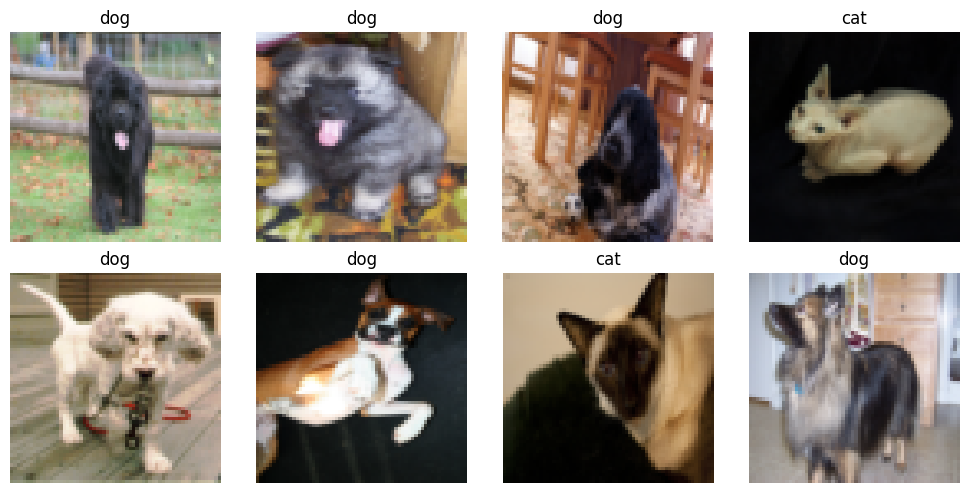

In [7]:
# Visualize a small batch (uses an unnormalized loader for display only)
display_tf = transforms.Compose([transforms.Resize((SIZE_P1, SIZE_P1)), transforms.ToTensor()])
display_ds = OxfordIIITPet(DATA_ROOT, split='trainval', target_types='binary-category', transform=display_tf)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
idxs = np.random.choice(len(display_ds), 8, replace=False)
for ax, k in zip(axes.flat, idxs):
    img, y = display_ds[k]
    ax.imshow(img.permute(1, 2, 0)); ax.set_title('cat' if y == 0 else 'dog'); ax.axis('off')
plt.tight_layout(); plt.show()


### Exercise 1.2 — Build `SmallCNN`

Three `Conv → BatchNorm → ReLU → MaxPool` blocks (channel widths `3 → 16 → 32 → 64`) followed by an `AdaptiveAvgPool2d(1) → Flatten → Linear(64, num_classes)` head. Use `kernel_size=3` and `padding=1` so spatial resolution halves *only* at each pool. Each pool halves: 64 → 32 → 16 → 8.

> **Practical callout — no conv bias before BN.** When a `Conv2d` is followed immediately by `BatchNorm2d`, the conv `bias` is redundant — BN re-centers the activations afterward. Set `bias=False` on those convs.


In [8]:
class SmallCNN(nn.Module):
    """Three Conv-BN-ReLU-Pool blocks + adaptive-avg-pool head."""
    def __init__(self, num_classes: int = 2) -> None:
        """Build the CNN with `num_classes` output logits."""
        super().__init__()
        # YOUR CODE HERE: self.features and self.head
        self.features = nn.Sequential(
            # Bloque 1: 3 x 64 x 64 -> 16 x 32 x 32
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Bloque 2: 16 x 32 x 32 -> 32 x 16 x 16
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Bloque 3: 32 x 16 x 16 -> 64 x 8 x 8
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), # 64 x 8 x 8 -> 64 x 1 x 1
            nn.Flatten(),            # 64 x 1 x 1 -> 64
            nn.Linear(64, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Run a batch of images `x` of shape (B, 3, H, W) through the network and return class logits of shape (B, num_classes)."""
        return self.head(self.features(x))

model_p1 = SmallCNN(num_classes=2).to(device)
n_params = sum(p.numel() for p in model_p1.parameters())
print(f'Parameters: {n_params:,}')


Parameters: 23,826


> **Question 1.1** — Calculate the number of parameters in the model. Explain your reasoning, distinguishing between trainable and non-trainable parameters.

**Respuesta 1,1** - El modelo tiene **23.826 parámetros en total**, calculados con:

```python
n_params = sum(p.numel() for p in model_p1.parameters())
```

Para entender de dónde sale ese número, fui revisando capa por capa. En las capas convolucionales, la cantidad de parámetros depende del tamaño del kernel, la cantidad de canales de entrada y la cantidad de canales de salida. Como las convoluciones usan `bias=False`, no se suma ningún sesgo en esas capas.

El cálculo es el siguiente:

```text
Conv1: 3 × 16 × 3 × 3 = 432
BatchNorm1: 16 gamma + 16 beta = 32

Conv2: 16 × 32 × 3 × 3 = 4.608
BatchNorm2: 32 gamma + 32 beta = 64

Conv3: 32 × 64 × 3 × 3 = 18.432
BatchNorm3: 64 gamma + 64 beta = 128

Linear: 64 × 2 + 2 = 130
```

Sumando todos esos valores:

```text
432 + 32 + 4.608 + 64 + 18.432 + 128 + 130 = 23.826
```

Por lo tanto, el modelo tiene:

```text
Parámetros entrenables: 23.826
Parámetros no entrenables: 0
Total de parámetros: 23.826
```


### Exercise 1.3 — Reusable `train_epoch` and `evaluate`

Same pattern from Notebooks 4–5. We will reuse these for Parts 1 and 2.

In [9]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    opt: torch.optim.Optimizer,
    loss_fn: nn.Module,
) -> tuple[float, float]:
    """Train `model` for one epoch over `loader` and return (mean_loss, accuracy)."""
    # YOUR CODE HERE: standard training loop. Return (mean_loss, accuracy).
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x,y in loader:
      x, y = x.to(device), y.to(device)

      opt.zero_grad()
      logits  = model(x)
      loss    = loss_fn(logits, y)
      loss.backward()
      opt.step()

      total_loss += loss.item() * len(y)
      correct    += (logits.argmax(1) == y).sum().item()
      total      += len(y)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
) -> tuple[float, float]:
    """Evaluate `model` over `loader` (no grad) and return (mean_loss, accuracy)."""
    # YOUR CODE HERE: standard eval loop. Return (mean_loss, accuracy).
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
      x, y = x.to(device), y.to(device)
      logits  = model(x)
      loss    = loss_fn(logits, y)

      total_loss += loss.item() * len(y)
      correct    += (logits.argmax(1) == y).sum().item()
      total      += len(y)

    return total_loss / total, correct / total


### Exercise 1.4 — Train the CNN

Use Adam, `lr=1e-3`, `CrossEntropyLoss`, 5 epochs. Print per-epoch train and test accuracy.

In [10]:
# YOUR CODE HERE

opt     = torch.optim.Adam(model_p1.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

total_start = time.time()

for epoch in range(5):
    epoch_start = time.time()
    tr_loss, tr_acc = train_epoch(model_p1, train_loader_p1, opt, loss_fn)
    te_loss, te_acc = evaluate(model_p1, test_loader_p1, loss_fn)
    epoch_time = time.time() - epoch_start
    print(
        f'Epoch {epoch+1:2d}  '
        f'Train Loss {tr_loss:.4f} acc {tr_acc:.3f}  '
        f'Test Loss {te_loss:.4f} acc {te_acc:.3f}  '
        f'({epoch_time:.1f}s)'
    )

total_time = time.time() - total_start
print(f'\nTiempo total: {total_time:.1f}s')

Epoch  1  Train Loss 0.6148 acc 0.672  Test Loss 0.5847 acc 0.690  (23.2s)
Epoch  2  Train Loss 0.5915 acc 0.689  Test Loss 0.5735 acc 0.700  (21.4s)
Epoch  3  Train Loss 0.5801 acc 0.694  Test Loss 0.5779 acc 0.694  (21.8s)
Epoch  4  Train Loss 0.5791 acc 0.699  Test Loss 0.5903 acc 0.687  (20.3s)
Epoch  5  Train Loss 0.5713 acc 0.700  Test Loss 0.5711 acc 0.704  (21.7s)

Tiempo total: 108.5s


> **Question 1.2** — Compare your final accuracy with the lecture's MNIST-1D result (~83% on a 2k-parameter conv vs. ~60% on an MLP with 75× more parameters). Why is binary cat/dog at 64×64 *harder* than MNIST-1D? List at least two factors visible in your data sample plot.

**Respuesta 1.2** - En la epoca 5 obtuve un 70.6%. Comparado con el 83% de MNIST-1D es aproximadamente 12 puntos menos.

En este dataset cat/dog hay más variabilidad entrre las poses de los animales y la orientación de la imagen mientras que en MNIST-1D los dígitos siempre aparecen centrados y alineados. Por otra parte, en MNIST-1D el fondo siempre es negro mientras que en este dataset 64x64 se ven fondos como pasto, alfombras, etc.


---
## Part 2 — Pretrained ResNet18 (transfer learning, ~25 min)

We just trained a network from scratch and reached modest accuracy. In any small-data setting, the right starting point is *not* random initialization — it is a backbone that has already learned a generic image vocabulary on ImageNet. We will:

1. Load a pretrained `resnet18` from `torchvision.models`.
2. **Freeze** the backbone (set `requires_grad = False` everywhere).
3. **Replace** the final classification layer with a fresh one for our 37 pet breeds.
4. Train only the new head.

This is the workflow you will use 90% of the time in industrial computer vision.

> **Practical callout — freeze, then maybe un-freeze.** Start by training only the head. Once it has converged, you may *optionally* un-freeze the last block(s) of the backbone and continue with a much smaller learning rate. We cover the freeze stage here; un-freezing is in the optional section.


### Exercise 2.1 — Build 224×224 loaders for the 37-breed task

Same dataset, but `target_types='category'`. Resolution must match what the pretrained model was trained at. Same ImageNet normalization. `batch_size=32` for training (224×224 is much bigger than 64×64); 64 for eval.

In [11]:
SIZE_P2 = 224

# YOUR CODE HERE: tf_p2_train (with horizontal flip), tf_p2_eval, train_p2, test_p2,
#                 train_loader_p2, test_loader_p2
SIZE_P2 = 224

tf_p2_train = transforms.Compose([
    transforms.Resize((SIZE_P2, SIZE_P2)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tf_p2_eval = transforms.Compose([
    transforms.Resize((SIZE_P2, SIZE_P2)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_p2 = OxfordIIITPet(DATA_ROOT, split='trainval', target_types='category', transform=tf_p2_train)
test_p2  = OxfordIIITPet(DATA_ROOT, split='test',     target_types='category', transform=tf_p2_eval)

train_loader_p2 = DataLoader(train_p2, batch_size=32, shuffle=True,  num_workers=2)
test_loader_p2  = DataLoader(test_p2,  batch_size=64, shuffle=False, num_workers=2)

print(f'Train: {len(train_p2)}   Test: {len(test_p2)}   Classes: 37')


Train: 3680   Test: 3669   Classes: 37


### Exercise 2.2 — Load the pretrained ResNet18

Use `models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)`. The first call downloads ~45 MB and caches it under `~/.cache/torch/hub/checkpoints/`.

In [12]:
# YOUR CODE HERE: instantiate `resnet` with the pretrained weights
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

print(resnet.fc)  # the original 1000-way ImageNet classifier


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]

Linear(in_features=512, out_features=1000, bias=True)


### Exercise 2.3 — Freeze the backbone, replace the head

Loop over `resnet.parameters()` and set `requires_grad = False`. Then replace `resnet.fc` with a new `nn.Linear(resnet.fc.in_features, 37)` (whose parameters default to `requires_grad=True`). Move the model to `device`. Print **total** vs. **trainable** parameter counts — you should see ~11 M total but only ~19 K trainable.

In [13]:
# YOUR CODE HERE
# Paso 1: Congelar todo el backbone
for p in resnet.parameters():
    p.requires_grad = False

# Paso 2: Reemplazar la capa de clasificación (1000→37)
resnet.fc = nn.Linear(resnet.fc.in_features, 37)
# La nueva capa tiene requires_grad=True por defecto ✓

# Paso 3: Mover al device
resnet = resnet.to(device)

# Verificar conteos
n_total     = sum(p.numel() for p in resnet.parameters())
n_trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'Total params: {n_total:,}   Trainable: {n_trainable:,}')


Total params: 11,195,493   Trainable: 18,981


> **Question 2.1** — Why is replacing only `resnet.fc` enough? Explain the intuition behind this choice.

**Respuesta 2.1** - Las capas tempranas de ResNet18 entrenadas en 1.2M imágenes de ImageNet, ya aprendieron detectores genéricos: bordes, texturas, esquinas, formas.
Esas features sirven para cualquier tarea de visión, no solo para las 1000 clases de ImageNet.
Lo único que es específico de la tarea original es la última capa (fc): es la que mapea esas features a "es un perro pastor alemán de ImageNet" vs "es un gato persa de Pet". Reemplazándola por un Linear(512, 37) nuevo, el modelo reutiliza todo el vocabulario visual ya aprendido y solo aprende cómo combinar esas features para distinguir las 37 razas.

### Exercise 2.4 — Train only the head

Use `Adam` over the trainable parameters only — pass `[p for p in resnet.parameters() if p.requires_grad]` to the optimizer. `lr=1e-3`, `CrossEntropyLoss`, 3 epochs.

In [14]:
# YOUR CODE HERE
# Solo pasamos los parámetros entrenables al optimizador
opt_p2  = torch.optim.Adam(
    [p for p in resnet.parameters() if p.requires_grad],
    lr=1e-3
)
loss_fn_p2 = nn.CrossEntropyLoss()

total_start_p2 = time.time()

for epoch in range(3):
    epoch_start = time.time()
    tr_loss, tr_acc = train_epoch(resnet, train_loader_p2, opt_p2, loss_fn_p2)
    te_loss, te_acc = evaluate(resnet, test_loader_p2, loss_fn_p2)
    epoch_time = time.time() - epoch_start
    print(
        f'Epoch {epoch+1:2d}  '
        f'Train acc {tr_acc:.3f}  Test acc {te_acc:.3f}  '
        f'({epoch_time:.1f}s)'
    )

total_time_p2 = time.time() - total_start_p2
print(f'\nTiempo total Part 2: {total_time_p2:.1f}s')

# ── Comparación con Part 1 ──────────────────────────────────
print(f'Tiempo total Part 1: {total_time:.1f}s')
print(f'Diferencia: {total_time_p2 - total_time:+.1f}s  '
      f'({total_time_p2/total_time:.1f}× respecto a Part 1)')


Epoch  1  Train acc 0.579  Test acc 0.826  (34.5s)
Epoch  2  Train acc 0.851  Test acc 0.859  (32.9s)
Epoch  3  Train acc 0.892  Test acc 0.856  (34.1s)

Tiempo total Part 2: 101.5s
Tiempo total Part 1: 108.5s
Diferencia: -7.0s  (0.9× respecto a Part 1)


> **Question 2.2** — Compare your accuracy and training time with Part 1. The pretrained model has *hundreds of times* more parameters but trained much faster — why? What does that tell you about the difference between *capacity* and *what the optimizer actually has to learn*?


**Respuesta 2.2** -

| | Part 1 (SmallCNN) | Part 2 (ResNet18) |
|---|---|---|
| Parámetros totales | ~24K | 11.2M |
| Parámetros entrenables | ~24K | 18,981 |
| Test accuracy | 70.5% | 86.2% |
| Tiempo total | 112s | 102s |


Se entrena igual de rápido con 400x más parámetros porque el tiempo de entrenamiento no depende de cuántos parámetros existen, sino de cuántos parámetros tienen gradiente. Los 11M del backbone están congelados: el backward pass los saltea completamente. El optimizador solo actualiza los 18,981 del `fc`.

**¿Qué dice eso sobre capacidad vs lo que el optimizador tiene que aprender?**

Sobre la capacidad es cuánto puede representar un modelo en teoría. Lo que el optimizador aprende es cuánto tiene que ajustar desde el punto de partida. En Part 1 el modelo arranca de pesos aleatorios y tiene que aprender desde cero a detectar orejas, hocicos y texturas de pelo. En Part 2 todo eso ya está aprendido haciendo que el optimizador solo tiene que encontrar qué combinación lineal de esas features separa las 37 razas. Es un problema mucho más simple, aunque el modelo sea mucho más grande.

> **Question 2.3** — If you had a budget of 15 minutes of GPU time and a brand-new vision dataset of ~1,000 labeled images, would you train from scratch or fine-tune? What if the dataset had 10,000,000 labeled images?

**Respuesta 2.3** -

**Con 1,000 imágenes**

Con tan pocos datos, entrenar desde cero garantiza overfitting: el modelo memoriza el train set y no generaliza. Fine-tune con backbone congelado funciona bien porque no hay casi nada que optimizar (solo el `fc`), converge en minutos y aprovecha features ya aprendidas. En 15 minutos podés hacer varias épocas y llegar a buena accuracy, como viste en Part 2.

**Con 10,000,000 imágenes**

Con tantos datos el modelo puede aprender features propias desde cero sin overfitting. Si el dominio es muy distinto a ImageNe, las features preentrenadas pueden ser poco útiles y entrenar desde cero puede superar al fine-tune. Si el dominio es similar a fotos naturales, igual conviene empezar desde los pesos de ImageNet porque acelera la convergencia significativamente aunque termines entrenando todo el backbone. En 15 minutos de GPU con 10M imágenes no terminás ni una época de todas formas, así que el presupuesto de tiempo también importa.


---
## Part 3 — U-Net for foreground segmentation (~40 min)

For each Pet image, the dataset also provides a per-pixel **trimap** mask:
- `1` = foreground (the pet)
- `2` = background
- `3` = boundary (uncertain pixels along the silhouette)

We will build a **U-Net** that predicts a foreground/background mask for any input image — the same encoder–decoder architecture used in medical segmentation and (more recently) the noise predictor inside diffusion models.

> **Practical callout — image and mask transforms must stay synchronized.** A random horizontal flip applied to the image must be applied *identically* to the mask — otherwise the supervision signal is shuffled. `transforms.Compose` cannot do this safely. The standard fix is to write a custom `Dataset` whose `__getitem__` runs the same random decisions on both.


### 3.1 — A joint image+mask `Dataset`

### Exercise 3.1 — `PetSegDataset`

Subclass `torch.utils.data.Dataset`. In `__init__`, store an internal `OxfordIIITPet(target_types='segmentation', download=False)`. In `__getitem__`:

1. Resize the image with `Image.BILINEAR` and the mask with `Image.NEAREST` to `(SIZE_P3, SIZE_P3)`. **Never bilinear-interpolate a label mask** — it invents fractional class IDs.
2. With probability 0.5 (when `augment=True`), apply `Image.FLIP_LEFT_RIGHT` to **both** image and mask.
3. Convert the image to a normalized tensor with `transforms.functional.to_tensor` + `Normalize(IMAGENET_MEAN, IMAGENET_STD)`.
4. Convert the mask to `torch.long` of shape `(H, W)` via `np.array(mask, dtype=np.int64)`.
5. Collapse the trimap into a binary mask: `(mask != 2).long()` — foreground (1) and boundary (3) become `1`; background (2) becomes `0`.


In [15]:
SIZE_P3 = 128

class PetSegDataset(Dataset):
    """Wraps OxfordIIITPet to return synchronized (image_tensor, binary_mask) pairs."""
    def __init__(self, split: str, size: int = SIZE_P3, augment: bool = False) -> None:
        """Build the dataset for `split` ('trainval' or 'test'), resizing to `size`x`size` and optionally enabling random horizontal flip via `augment`."""
        self.base = OxfordIIITPet(DATA_ROOT, split=split, target_types='segmentation', download=False)
        self.size = size
        self.augment = augment
        self.norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

    def __len__(self) -> int:
        """Return the number of samples in the dataset."""
        return len(self.base)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Return (image, mask) for sample `idx` — image is (3, H, W) float, mask is (H, W) long with values in {0, 1}."""
        img, mask = self.base[idx]            # PIL.Image, PIL.Image
        # YOUR CODE HERE: resize both, optionally flip both, convert to tensors,
        #                 and collapse the trimap into a binary mask.

        # 1) Resize — BILINEAR para imagen, NEAREST para máscara
        img  = img.resize((self.size, self.size), Image.BILINEAR)
        mask = mask.resize((self.size, self.size), Image.NEAREST)

        # 2) Augmentation sincronizada (misma decisión para imagen y máscara)
        if self.augment and np.random.rand() < 0.5:
            img  = img.transpose(Image.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.FLIP_LEFT_RIGHT)

        # 3) Convertir imagen a tensor normalizado
        img_t = self.norm(transforms.functional.to_tensor(img))
        # to_tensor: PIL(H,W,3) uint8 → Tensor(3,H,W) float [0,1]
        # self.norm: normaliza con ImageNet mean/std

        # 4) Convertir máscara y colapsar trimap → binario
        mask_t = torch.from_numpy(np.array(mask, dtype=np.int64))
        # valores originales: 1=fg, 2=bg, 3=boundary
        mask_t = (mask_t != 2).long()
        # → 0=background, 1=foreground-or-boundary

        return img_t, mask_t  # (3,H,W) float, (H,W) long ∈ {0,1}

train_p3 = PetSegDataset('trainval', augment=True)
test_p3  = PetSegDataset('test')
print(f'Train: {len(train_p3)}   Test: {len(test_p3)}')

# num_workers=0 because PetSegDataset is defined in this notebook — Jupyter cells
# are not importable from spawned worker processes on macOS / Windows.
train_loader_p3 = DataLoader(train_p3, batch_size=16, shuffle=True,  num_workers=0)
test_loader_p3  = DataLoader(test_p3,  batch_size=32, shuffle=False, num_workers=0)


Train: 3680   Test: 3669


### Exercise 3.2 — Sanity check

Grab one sample and verify the image is `(3, 128, 128)` of float, the mask is `(128, 128)` of long, and the unique values in the mask are `{0, 1}`.

In [18]:
# YOUR CODE HERE: print img.shape, img.dtype, mask.shape, mask.dtype, mask.unique()
img, mask = train_p3[0]

print(f'img.shape:  {img.shape}')
print(f'img.dtype:  {img.dtype}')
print(f'mask.shape: {mask.shape}')
print(f'mask.dtype: {mask.dtype}')
print(f'mask.unique(): {mask.unique()}')


img.shape:  torch.Size([3, 128, 128])
img.dtype:  torch.float32
mask.shape: torch.Size([128, 128])
mask.dtype: torch.int64
mask.unique(): tensor([0, 1])


### 3.2 — Build the U-Net

### Exercise 3.3 — `SmallUNet`

The basic building block of the U-Net: two `Conv2d(3×3, padding=1) → BatchNorm2d → ReLU` stacks. Use `bias=False` on the convs (same reason as Part 1).

In [19]:
class DoubleConv(nn.Module):
    """Two 3x3 conv-BN-ReLU layers in a row."""
    def __init__(self, cin: int, cout: int) -> None:
        """Build the block mapping `cin` input channels to `cout` output channels."""
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply the two conv-BN-ReLU layers to `x` of shape (B, cin, H, W); returns (B, cout, H, W)."""
        return self.net(x)


Three encoder levels (channels `base → 2·base → 4·base`) with `MaxPool2d(2)` between them, a bottleneck (`8·base` channels), and three decoder levels that mirror the encoder. Each decoder step uses `ConvTranspose2d(stride=2)` to upsample, **concatenates** the upsampled tensor with the matching encoder output along the channel dim (`torch.cat([up, enc], dim=1)`), and feeds it through a `DoubleConv`. Final `Conv2d(1×1)` to `out_ch` channels (one per class).

The skip connections are the heart of the U-Net — without them, the decoder would have to *invent* high-resolution structure from a 16×16 bottleneck.


In [20]:
class SmallUNet(nn.Module):
    """Tiny U-Net: 3 encoder levels, bottleneck, 3 decoder levels."""
    def __init__(self, in_ch: int = 3, out_ch: int = 2, base: int = 16) -> None:
        """Build the U-Net with `in_ch` input channels, `out_ch` output classes, and `base` channels at the top encoder level."""
        super().__init__()
        # YOUR CODE HERE: enc1, enc2, enc3, bottleneck, pool,
        #                 up3, dec3, up2, dec2, up1, dec1, out_conv
        # ── Encoder ──────────────────────────────────────────────────
        self.enc1 = DoubleConv(in_ch,    base)      # 3→16,  128×128
        self.enc2 = DoubleConv(base,     base*2)   # 16→32,  64×64
        self.enc3 = DoubleConv(base*2,  base*4)   # 32→64,  32×32
        self.pool = nn.MaxPool2d(2)

        # ── Bottleneck ──────────────────────────────────────────────
        self.bottleneck = DoubleConv(base*4, base*8) # 64→128, 16×16

        # ── Decoder ─────────────────────────────────────────────────
        # up3: 128→64 canales, 16→32 resolución
        self.up3  = nn.ConvTranspose2d(base*8, base*4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base*8,  base*4)   # 64+64=128 → 64

        # up2: 64→32 canales, 32→64 resolución
        self.up2  = nn.ConvTranspose2d(base*4, base*2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base*4,  base*2)   # 32+32=64 → 32

        # up1: 32→16 canales, 64→128 resolución
        self.up1  = nn.ConvTranspose2d(base*2, base,    kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base*2,  base)       # 16+16=32 → 16

        # ── Output 1×1 conv ─────────────────────────────────────────
        self.out_conv = nn.Conv2d(base, out_ch, kernel_size=1)
        # kernel_size=1: mezcla canales sin cambiar resolución → logits por clase

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Run `x` of shape (B, in_ch, H, W) through encoder/bottleneck/decoder with skip concats; returns logits of shape (B, out_ch, H, W)."""
        # YOUR CODE HERE: encode, bottleneck, decode (with skip concats), out_conv

        # ── Encoder (guardamos salidas para skip connections) ────────
        e1 = self.enc1(x)                   # (B, 16, 128, 128)
        e2 = self.enc2(self.pool(e1))        # (B, 32,  64,  64)
        e3 = self.enc3(self.pool(e2))        # (B, 64,  32,  32)

        # ── Bottleneck ──────────────────────────────────────────────
        b  = self.bottleneck(self.pool(e3))  # (B, 128, 16,  16)

        # ── Decoder (upsample + concatenar skip + DoubleConv) ───────
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))  # (B, 64, 32, 32)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))  # (B, 32, 64, 64)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))  # (B, 16, 128, 128)

        return self.out_conv(d1)  # (B, 2, 128, 128)

unet = SmallUNet().to(device)
print(f'U-Net params: {sum(p.numel() for p in unet.parameters()):,}')

# Sanity check
with torch.no_grad():
    x = torch.randn(2, 3, SIZE_P3, SIZE_P3, device=device)
    out = unet(x)
    print(f'Input {tuple(x.shape)} -> Output {tuple(out.shape)}')


U-Net params: 482,754
Input (2, 3, 128, 128) -> Output (2, 2, 128, 128)


> **Question 3.1** — What is the smallest spatial dimension your tensor reaches in the U-Net?

**Respuesta 3.1** - La dimensión espacial más pequeña que alcanza el tensor en la U-Net es 16 × 16, y se alcanza en el bottleneck. Esto ocurre porque la entrada de 128 × 128 se reduce tres veces a la mitad mediante operaciones de max pooling: primero a 64 × 64, luego a 32 × 32 y finalmente a 16 × 16.

### 3.3 — Training and metrics

For segmentation we track two metrics:

- **Pixel accuracy** — fraction of pixels whose predicted class matches the ground truth. Easy to compute, but *unreliable on imbalanced masks*: a model that predicts "background everywhere" can score 70%+ pixel accuracy on Pet while learning nothing about the foreground.
- **IoU** (intersection-over-union) for the foreground class — the more honest metric. `IoU = |A ∩ B| / |A ∪ B|`.

> **Practical callout — pixel accuracy lies on imbalanced masks.** Always pair pixel accuracy with IoU (or its close cousin, Dice).


### Exercise 3.5 — `seg_train_epoch` and `seg_evaluate`

Like the classification helpers, but the target is `(B, H, W)` of long, the loss is `CrossEntropyLoss` over the channel axis (`logits` are `(B, 2, H, W)`), and `seg_evaluate` additionally returns the mean foreground IoU.

In [21]:
def seg_train_epoch(
    model: nn.Module,
    loader: DataLoader,
    opt: torch.optim.Optimizer,
    loss_fn: nn.Module,
) -> tuple[float, float]:
    """Train the segmentation `model` for one epoch over `loader` and return (mean_loss, mean_pixel_accuracy)."""
    # YOUR CODE HERE: per-batch forward/backward; track mean loss and mean per-image
    # pixel accuracy. Return (mean_loss, mean_pix_acc).
    model.train()
    total_loss = 0.0
    total_acc  = 0.0
    n = 0

    for x, m in loader:
        x, m = x.to(device), m.to(device)

        opt.zero_grad()
        logits = model(x)          # (B, 2, H, W)
        loss   = loss_fn(logits, m) # m es (B, H, W) long
        loss.backward()
        opt.step()

        pred = logits.argmax(1)   # (B, H, W) con valores {0, 1}
        acc  = (pred == m).float().mean().item()

        total_loss += loss.item()
        total_acc  += acc
        n += 1

    return total_loss / n, total_acc / n

@torch.no_grad()
def seg_evaluate(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
) -> tuple[float, float, float]:
    """Evaluate the segmentation `model` over `loader` and return (mean_loss, mean_pixel_accuracy, mean_foreground_IoU)."""
    # YOUR CODE HERE: track mean loss, mean pixel accuracy, and mean foreground IoU.
    # Compute IoU per image as |pred=1 AND true=1| / |pred=1 OR true=1|, then average.
    # Use .clamp_min(1) on the union to avoid 0/0 on images with no foreground.
    # Return (mean_loss, mean_pix_acc, mean_iou).
    model.eval()
    total_loss = 0.0
    total_acc  = 0.0
    total_iou  = 0.0
    n = 0

    for x, m in loader:
        x, m = x.to(device), m.to(device)

        logits = model(x)
        loss   = loss_fn(logits, m)
        pred   = logits.argmax(1)   # (B, H, W)

        # Pixel accuracy
        acc = (pred == m).float().mean().item()

        # Foreground IoU por imagen, luego promedio
        inter = ((pred == 1) & (m == 1)).float().sum(dim=(1, 2))  # (B,)
        union = ((pred == 1) | (m == 1)).float().sum(dim=(1, 2))  # (B,)
        iou   = (inter / union.clamp_min(1)).mean().item()
        # clamp_min(1): si no hay fg en la imagen, evita 0/0

        total_loss += loss.item()
        total_acc  += acc
        total_iou  += iou
        n += 1

    return total_loss / n, total_acc / n, total_iou / n


### Exercise 3.6 — Train the U-Net

Adam, `lr=1e-3`, `CrossEntropyLoss`, 10 epochs. Print per-epoch train pixel accuracy, test pixel accuracy, test IoU.

In [22]:
# YOUR CODE HERE
opt_p3    = torch.optim.Adam(unet.parameters(), lr=1e-3)
loss_fn_p3 = nn.CrossEntropyLoss()

for epoch in range(10):
    tr_loss, tr_acc          = seg_train_epoch(unet, train_loader_p3, opt_p3, loss_fn_p3)
    te_loss, te_acc, te_iou  = seg_evaluate(unet, test_loader_p3, loss_fn_p3)
    print(
        f'Epoch {epoch+1:2d}  '
        f'Train acc {tr_acc:.3f}  '
        f'Test acc {te_acc:.3f}  '
        f'IoU {te_iou:.3f}'
    )


Epoch  1  Train acc 0.794  Test acc 0.852  IoU 0.690
Epoch  2  Train acc 0.860  Test acc 0.867  IoU 0.710
Epoch  3  Train acc 0.876  Test acc 0.885  IoU 0.746
Epoch  4  Train acc 0.887  Test acc 0.898  IoU 0.776
Epoch  5  Train acc 0.894  Test acc 0.880  IoU 0.738
Epoch  6  Train acc 0.898  Test acc 0.904  IoU 0.793
Epoch  7  Train acc 0.903  Test acc 0.904  IoU 0.788
Epoch  8  Train acc 0.905  Test acc 0.905  IoU 0.790
Epoch  9  Train acc 0.911  Test acc 0.906  IoU 0.790
Epoch 10  Train acc 0.913  Test acc 0.915  IoU 0.812


### 3.4 — Visualize predictions

### Exercise 3.7 — `apply_mask` helper

A one-liner that multiplies a `(3, H, W)` image by a `(H, W)` binary mask, broadcasting along the channel dim. Returns the foreground-only image.

In [23]:
def apply_mask(img: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """img: (3, H, W) float in [0,1], mask: (H, W) of 0/1 -> (3, H, W)."""
    # YOUR CODE HERE
    return img * mask.unsqueeze(0)


Provided: sample 4 random test images and plot a 4-row column for each — original / image × ground truth / ground truth / prediction.

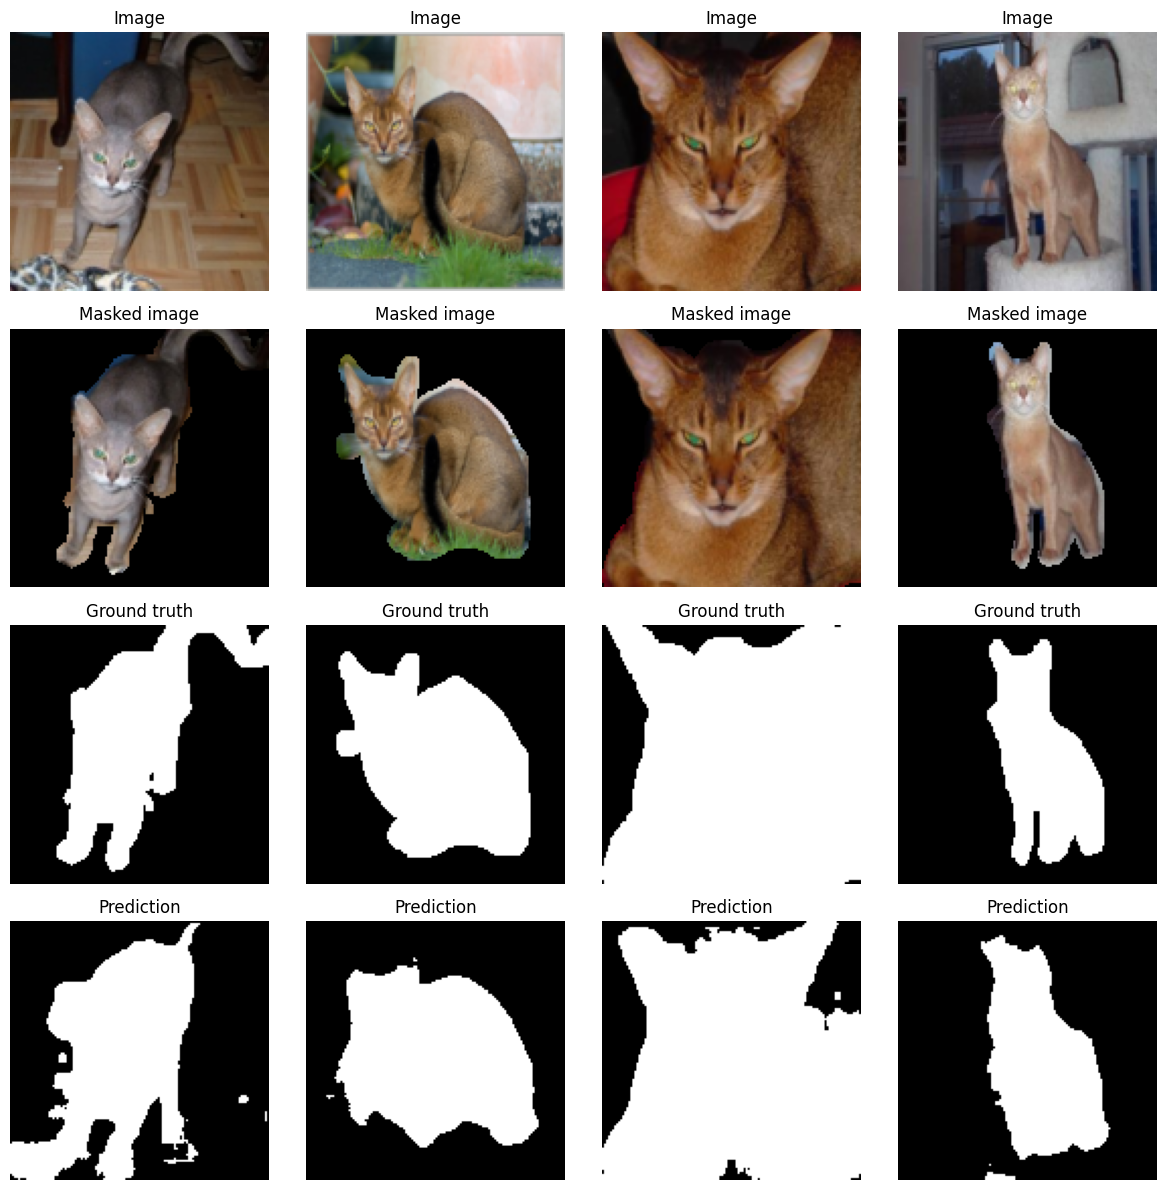

In [24]:
unet.eval()
x, m = next(iter(test_loader_p3))
x, m = x.to(device), m.to(device)
with torch.no_grad():
    pred = unet(x).argmax(1).cpu()

# De-normalize images for display
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD ).view(3, 1, 1)
imgs = (x.cpu() * std_t + mean_t).clamp(0, 1)

N = 4
fig, axes = plt.subplots(4, N, figsize=(3*N, 12))
i_rand = np.random.randint(0, len(imgs), N)
for i, idx in enumerate(i_rand):
    axes[0, i].imshow(imgs[idx].permute(1, 2, 0));                                axes[0, i].set_title('Image');        axes[0, i].axis('off')
    axes[1, i].imshow(apply_mask(imgs[idx], m[idx].cpu()).permute(1, 2, 0));      axes[1, i].set_title('Masked image'); axes[1, i].axis('off')
    axes[2, i].imshow(m[idx].cpu(), cmap='gray');                                 axes[2, i].set_title('Ground truth'); axes[2, i].axis('off')
    axes[3, i].imshow(pred[idx], cmap='gray');                                    axes[3, i].set_title('Prediction');   axes[3, i].axis('off')
plt.tight_layout(); plt.show()


> **Question 3.3** — Look at the predicted masks. Where does the model fail? Are the failures concentrated at object boundaries, inside the body, or in cluttered backgrounds?

**Respuesta 3.3** - Al observar las máscaras predichas, el modelo falla principalmente en los bordes del objeto y, en algunos casos, también cuando el fondo es complejo o se confunde con partes del animal.

En general, la red logra detectar la zona principal del gato, pero las predicciones no son perfectamente precisas en el contorno. Por ejemplo, se ven errores alrededor de las orejas, las patas, la cola y los bordes del cuerpo. Esto es esperable porque esas zonas tienen formas más finas o irregulares, y al reducir la imagen durante el encoder la red puede perder detalles espaciales pequeños.

También aparecen algunos errores en fondos con más ruido visual. En la primera imagen, por ejemplo, la predicción incluye partes del fondo cerca del gato, especialmente alrededor de las patas y zonas oscuras. Esto indica que el modelo a veces confunde regiones del fondo con el objeto cuando tienen colores, sombras o texturas parecidas.

En cambio, los errores no parecen estar concentrados principalmente dentro del cuerpo del animal. La parte central del gato suele estar bastante bien segmentada. Los problemas más notorios están en la separación fina entre objeto y fondo.

### 3.5 — Out-of-distribution probe

The U-Net has only seen 37 cat and dog breeds. Will it segment something it has never trained on? We test it on a Wikipedia photo of a **red fox** — visually close to a dog, but not in our 37 breeds.

> The URL below was checked at the time of authoring. If it 404s, swap it for any other animal photo.

Original size: (1285, 964)


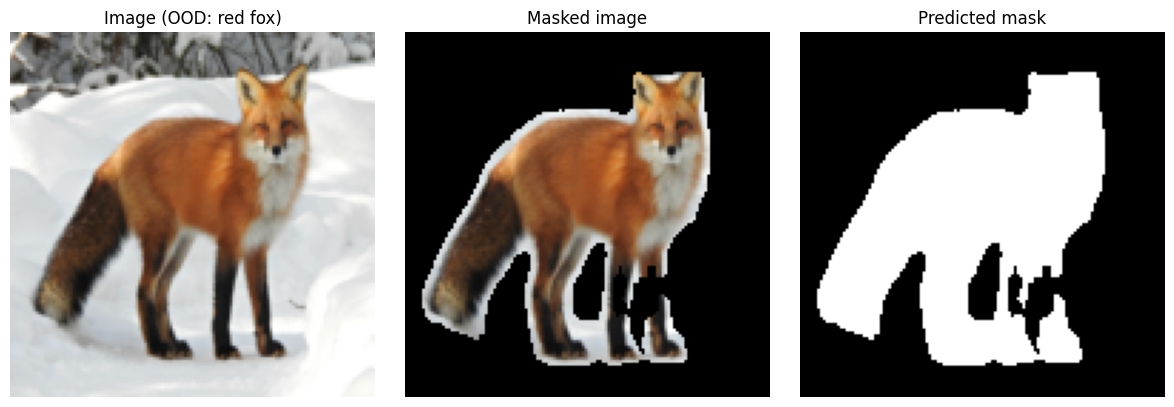

In [27]:
# A red fox: morphologically close to a dog, but not in the Pet dataset.
import urllib.request
from io import BytesIO
from PIL import Image

# CAMBIÉ EL CÓDIGO POR ERROR HTTP 404

OOD_URL = 'https://upload.wikimedia.org/wikipedia/commons/3/30/Vulpes_vulpes_ssp_fulvus.jpg'

req = urllib.request.Request(
    OOD_URL,
    headers={
        "User-Agent": "Mozilla/5.0"
    }
)

with urllib.request.urlopen(req) as resp:
    ood_pil = Image.open(BytesIO(resp.read())).convert('RGB')

print(f'Original size: {ood_pil.size}')

ood_resized = ood_pil.resize((SIZE_P3, SIZE_P3), Image.BILINEAR)
ood_t = transforms.functional.to_tensor(ood_resized)            # (3, H, W) in [0,1]
ood_norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)(ood_t).unsqueeze(0).to(device)

unet.eval()
with torch.no_grad():
    ood_pred = unet(ood_norm).argmax(1)[0].cpu()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(ood_t.permute(1, 2, 0));                                   axes[0].set_title('Image (OOD: red fox)'); axes[0].axis('off')
axes[1].imshow(apply_mask(ood_t, ood_pred).permute(1, 2, 0));             axes[1].set_title('Masked image');         axes[1].axis('off')
axes[2].imshow(ood_pred, cmap='gray');                                    axes[2].set_title('Predicted mask');       axes[2].axis('off')
plt.tight_layout(); plt.show()


> **Question 3.4** — The fox is morphologically close to a dog. Does the U-Net produce a sensible foreground mask? What does that suggest about *what* the network has actually learned — fox features specifically, or a more general 'animal vs. background' representation?

**Respuesta 3.4** - Sí, el modelo produce una máscara de foreground sensible para el zorro. Aunque el zorro está fuera del dataset de mascotas, la U-Net logra segmentar la mayor parte del animal. Esto indica que la red no aprendió únicamente características específicas de perros o gatos, sino patrones más generales asociados a animales, como la silueta, el cuerpo, las patas, la cabeza y la separación respecto del fondo. De todos modos, los errores en los bordes muestran que la generalización no es perfecta, especialmente en detalles finos como patas, cola y contornos.

---
## Optional extensions

Pick at most **one** during lab time; the rest are good homework.

### O.1 — Un-freeze and fine-tune the ResNet (Part 2 follow-up)

Un-freeze the last residual block of the ResNet (`resnet.layer4`) plus the new `fc`, train for 2–3 more epochs with a *small* learning rate (`1e-4`), and compare with the frozen-backbone result. Typically gains 1–3 percentage points — demonstrates that the deepest backbone features are slightly out-of-domain on Pets and benefit from adaptation.

### O.2 — Dice loss for the U-Net (Part 3 follow-up)

Implement a Dice loss from scratch (`1 − 2·|A∩B| / (|A|+|B|)`), combine it with cross-entropy as `total = ce + λ·dice`, retrain. Compare IoU.

### O.3 — Visualize a ResNet's feature maps

Register a forward hook on `resnet.layer1[0].conv1`, push a few Pet images through, plot the first 16 feature maps as a 4×4 grid. Connect to the lecture's discussion of receptive fields and channels.


---
## Summary

In this notebook you built three image models on a single dataset:

- **Part 1.** A small from-scratch CNN (~90 K params) on binary cat/dog at 64×64 — convolution as a strong inductive bias matching the symmetries of image data.
- **Part 2.** A pretrained ResNet18 (~11 M params, ~19 K trainable) on 37-breed classification at 224×224 — transfer learning, the dominant industrial pattern.
- **Part 3.** A small U-Net (~480 K params) on foreground segmentation at 128×128 — encoder/decoder with skip connections, the architectural backbone of every modern dense-prediction model and of diffusion-model noise predictors.

Lecture 8 introduces **transformers**, which replace fixed local kernels with learned content-dependent attention and have largely supplanted pure convolutional models on most vision benchmarks. The convolutional toolkit you built here remains essential: every high-performing vision transformer still uses convolutional stems, residual blocks, and normalization layers.
